# Layer 3. Predictive Customer Analytics

**Бизнес-контекст:**  

Предыдущие разделы проекта позволили определить механизмы деградации клиентской базы, оценить долгосрочную ценность клиентов и выявить основные источники потерь выручки. Однако описательный анализ отвечает преимущественно на вопрос, что уже произошло.

Следующим логическим шагом становится переход к прогнозированию будущего поведения клиентов. Для эффективного управления retention-стратегией компании необходимо заранее выявлять пользователей с высоким риском ухода, оценивать потенциальные финансовые потери и определять клиентов, для которых удержание способно принести максимальный бизнес-эффект.

**Основная задача раздела:**  

Построить систему предиктивной аналитики, позволяющую:
- прогнозировать риск оттока клиентов,
- оценивать потенциальную ценность пользователей,
- выявлять клиентов с высоким revenue-at-risk,
- определять приоритетные сегменты для retention-кампаний,
- оценивать вероятность успешной реактивации клиентов.

**Исследовательские вопросы:**
1. Какие поведенческие факторы наиболее сильно связаны с вероятностью оттока клиентов?
2. Возможно ли заранее идентифицировать пользователей с высоким риском потери до фактического прекращения покупательской активности?
3. Какие клиенты одновременно обладают:
   - высоким churn-risk,
   - высокой текущей или ожидаемой ценностью,
   - высоким потенциалом реактивации?
4. Как распределяется потенциальная потеря выручки между различными сегментами клиентской базы?
5. Какие сегменты являются наиболее приоритетными с точки зрения retention-инвестиций?
6. Насколько эффективно можно объединить churn-risk, customer value и recovery potential в единую систему принятия retention-решений?

**Гипотезы:**
1. Снижение покупательской частоты и ухудшение transactional dynamics являются ранними индикаторами вероятного оттока клиента.
2. Поведенческие тренды (изменение Frequency и Monetary) обладают большей прогностической ценностью, чем статические RFM-показатели.
3. Наибольший бизнес-риск формируют клиенты, которые одновременно имеют:
   - высокий churn probability,
   - высокий expected future revenue,
   - положительный потенциал реактивации.
4. Не все клиенты с высоким риском оттока являются экономически целесообразными для retention-инвестиций, поэтому приоритизация должна учитывать одновременно риск, ценность и вероятность восстановления активности.

**Методология:**  

Анализ реализован в формате time-based predictive modeling.  
Для каждого временного snapshot формируется набор пользовательских признаков, отражающих:
 - Recency: давность последней покупки;
 - Frequency: интенсивность покупок;
 - Monetary: объем выручки;
 - transactional cadence: средний интервал между покупками;
 - behavioral trends: динамику изменения частоты и выручки;
 - growth metrics: темпы изменения покупательской активности.

Пользователи дополнительно классифицируются по стадиям жизненного цикла:
 - New
 - Active
 - Loyal
 - At Risk
 - Churn

Для прогнозирования вероятности оттока используется Random Forest Classifier с time-based split, что позволяет избежать temporal leakage и приблизить модель к реальному production-сценарию.

**Целевая переменная:**  

Клиент считается склонным к оттоку, если в следующем временном периоде переходит в стадии:
 - At Risk
 - Churn

**Дополнительно реализованы:**  

Дополнительно реализованы:   
1. SHAP-анализ для интерпретации факторов риска и объяснения решений модели;  
2. Risk Segmentation Framework для разделения клиентской базы по уровням вероятности оттока;  
3. Customer Value Framework для оценки текущей и ожидаемой экономической значимости клиентов;  
4. Revenue-at-Risk Framework для количественной оценки потенциальных финансовых потерь;  
5. Retention Prioritization Framework, объединяющий churn-risk, expected future revenue и recovery potential в единый показатель приоритета удержания;  
6. Recovery Scoring Framework для оценки потенциала реактивации клиентов сегмента At Risk.  

**Бизнес-интерпретация:**  

Данный подход позволяет перейти от реактивного управления оттоком к проактивной retention-стратегии.
Вместо массовых коммуникаций компания получает возможность:
 - выявлять клиентов с максимальным риском потери;
 - оценивать потенциальный объем revenue-at-risk;
 - концентрировать retention-бюджет на наиболее ценных и "спасаемых" пользователях;
 - снижать неэффективные маркетинговые расходы;
 - повышать ROI CRM-коммуникаций.

Ключевое отличие данного подхода заключается в том, что решение об удержании принимается не только на основе риска оттока. Компания получает возможность учитывать одновременно вероятность потери клиента, его экономическую значимость и ожидаемую эффективность retention-вмешательства.

**Практический результат:**  

Итогом анализа является формирование системы приоритизации retention-инвестиций, основанной на:
 - вероятности оттока,
 - ожидаемой будущей выручке,
 - вероятности успешной реактивации клиента.

Таким образом, аналитическая система переходит от прогнозирования риска к управлению риском. Вместо ответа на вопрос «кто уйдет?» компания получает инструмент для ответа на вопрос «кого необходимо удерживать в первую очередь и где retention-инвестиции создадут максимальную бизнес-ценность»

**Период анализа:** 2021-07-12 — 2022-06-09

## Predictive Churn Modeling Framework

После исследования retention, customer value и lifecycle-динамики следующим шагом является переход от ретроспективного анализа к прогнозированию будущего поведения клиентов. На данном этапе оценивается возможность заранее выявлять пользователей, демонстрирующих признаки потенциального снижения активности, еще до фактического перехода в стадии At Risk или Churn.

Цель анализа — определить, насколько поведенческие характеристики клиентов позволяют прогнозировать риск оттока на горизонте следующего периода наблюдения, а также выявить факторы, наиболее тесно связанные с ухудшением пользовательской активности. Дополнительно проверяется гипотеза о том, что изменения покупательского поведения и динамика клиентской ценности обладают большей предиктивной силой, чем статические показатели клиентской активности.

Для анализа используется подход time-based predictive modeling. На последовательности исторических snapshot-срезов формируется набор behavioral-, transactional- и lifecycle-признаков, отражающих интенсивность покупок, объем расходов, регулярность взаимодействия и изменение пользовательского поведения во времени. В качестве целевого события рассматривается переход клиента в рискованные стадии жизненного цикла (At Risk или Churn) в следующем временном периоде. Для минимизации temporal leakage применяется временное разделение обучающей и тестовой выборок, максимально приближенное к реальному сценарию использования модели.

Ожидается, что ключевыми драйверами риска оттока окажутся ухудшение transactional dynamics, снижение покупательской частоты и замедление роста клиентской ценности. Подтверждение данной гипотезы позволит перейти от реактивного управления churn к проактивной системе раннего обнаружения клиентов с повышенным риском потери и сформировать основу для последующей приоритизации retention-инвестиций.

Построим time-based churn prediction model, оценим ее качество и проанализируем факторы, наиболее влияющие на вероятность оттока клиентов.

In [1]:
# =====================================================
# IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv('no_outliers_freq.csv')

df['datetime'] = pd.to_datetime(df['datetime'])

# =====================================================
# SNAPSHOT DATES
# =====================================================

snapshot_dates = pd.to_datetime([
    '2021-12-31',
    '2022-01-31',
    '2022-02-28',
    '2022-03-31',
    '2022-04-30',
    '2022-05-31'
])

# =====================================================
# ALL CUSTOMERS
# =====================================================

all_customers = pd.DataFrame({
    'card': df['card'].unique()
})

# =====================================================
# FIRST PURCHASE
# =====================================================

first_purchase = (
    df.groupby('card')['datetime']
    .min()
    .reset_index()
)

first_purchase.columns = [
    'card',
    'first_purchase_date'
]

# =====================================================
# CREATE SNAPSHOT
# =====================================================

def create_snapshot(data, snapshot_date):

    # -------------------------------------------------
    # HISTORY BEFORE SNAPSHOT
    # -------------------------------------------------

    history = data[
        data['datetime'] <= snapshot_date
    ].copy()

    # -------------------------------------------------
    # 6-MONTH WINDOW
    # -------------------------------------------------

    start_date = snapshot_date - pd.DateOffset(months=6)

    window = history[
        history['datetime'] >= start_date
    ].copy()

    # -------------------------------------------------
    # RECENCY
    # -------------------------------------------------

    recency = (
        history.groupby('card')['datetime']
        .max()
        .reset_index()
    )

    recency['Recency'] = (
        snapshot_date - recency['datetime']
    ).dt.days

    recency = recency[['card', 'Recency']]

    # -------------------------------------------------
    # FREQUENCY + MONETARY
    # -------------------------------------------------

    fm = (
        window.groupby('card')
        .agg({
            'doc_id': 'nunique',
            'summ_with_disc': 'sum'
        })
        .reset_index()
    )

    fm.columns = [
        'card',
        'Frequency',
        'Monetary'
    ]

    # -------------------------------------------------
    # AVG чек
    # -------------------------------------------------

    fm['Avg_Check'] = np.where(
        fm['Frequency'] > 0,
        fm['Monetary'] / fm['Frequency'],
        0
    )

    # -------------------------------------------------
    # DAYS BETWEEN PURCHASES
    # -------------------------------------------------

    purchase_gaps = (
        history
        .sort_values(['card', 'datetime'])
        .groupby('card')['datetime']
        .diff()
        .dt.days
    )

    history['gap_days'] = purchase_gaps

    gap_features = (
        history.groupby('card')
        .agg({
            'gap_days': 'mean'
        })
        .reset_index()
    )

    gap_features.columns = [
        'card',
        'Avg_Days_Between_Purchases'
    ]

    # -------------------------------------------------
    # MERGE
    # -------------------------------------------------

    rfm = all_customers.merge(
        recency,
        on='card',
        how='left'
    )

    rfm = rfm.merge(
        fm,
        on='card',
        how='left'
    )

    rfm = rfm.merge(
        gap_features,
        on='card',
        how='left'
    )

    rfm = rfm.merge(
        first_purchase,
        on='card',
        how='left'
    )

    # -------------------------------------------------
    # VALID CUSTOMERS
    # -------------------------------------------------

    rfm = rfm[
        rfm['first_purchase_date'] <= snapshot_date
    ]

    rfm = rfm[
        rfm['Recency'].notna()
    ]

    # -------------------------------------------------
    # FILL NULLS
    # -------------------------------------------------

    fill_cols = [
        'Frequency',
        'Monetary',
        'Avg_Check',
        'Avg_Days_Between_Purchases'
    ]

    for col in fill_cols:

        rfm[col] = rfm[col].fillna(0)

    # -------------------------------------------------
    # CUSTOMER AGE
    # -------------------------------------------------

    rfm['Customer_Age'] = (
        snapshot_date - rfm['first_purchase_date']
    ).dt.days

    # -------------------------------------------------
    # LIFECYCLE STAGE
    # -------------------------------------------------

    conditions = [

        (
            (rfm['Frequency'] == 1) &
            (rfm['Recency'] <= 31) &
            (rfm['Customer_Age'] <= 31)
        ),

        (
            (rfm['Frequency'] >= 4) &
            (rfm['Recency'] <= 88)
        ),

        (
            (rfm['Recency'] <= 88)
        ),

        (
            (rfm['Recency'].between(89, 184))
        ),

        (
            (rfm['Recency'] > 184)
        )
    ]

    stages = [
        'New',
        'Loyal',
        'Active',
        'At Risk',
        'Churn'
    ]

    rfm['Lifecycle_Stage'] = np.select(
        conditions,
        stages,
        default='Unknown'
    )

    rfm['Snapshot_Date'] = snapshot_date

    return rfm

# =====================================================
# BUILD SNAPSHOTS
# =====================================================

snapshots = []

for snapshot_date in snapshot_dates:

    snap = create_snapshot(
        df,
        snapshot_date
    )

    snapshots.append(snap)

all_snapshots = pd.concat(snapshots)

# =====================================================
# SORT
# =====================================================

all_snapshots = all_snapshots.sort_values([
    'card',
    'Snapshot_Date'
])

# =====================================================
# TEMPORAL FEATURES
# =====================================================

all_snapshots['Prev_Frequency'] = (
    all_snapshots
    .groupby('card')['Frequency']
    .shift(1)
)

all_snapshots['Prev_Monetary'] = (
    all_snapshots
    .groupby('card')['Monetary']
    .shift(1)
)

# -----------------------------------------------------
# DELTAS
# -----------------------------------------------------

all_snapshots['Frequency_Delta'] = (
    all_snapshots['Frequency']
    - all_snapshots['Prev_Frequency']
)

all_snapshots['Monetary_Delta'] = (
    all_snapshots['Monetary']
    - all_snapshots['Prev_Monetary']
)

# -----------------------------------------------------
# GROWTH RATES
# -----------------------------------------------------

all_snapshots['Frequency_Growth'] = np.where(
    all_snapshots['Prev_Frequency'] > 0,
    all_snapshots['Frequency']
    / all_snapshots['Prev_Frequency'],
    0
)

all_snapshots['Monetary_Growth'] = np.where(
    all_snapshots['Prev_Monetary'] > 0,
    all_snapshots['Monetary']
    / all_snapshots['Prev_Monetary'],
    0
)

# -----------------------------------------------------
# FILL NULLS
# -----------------------------------------------------

temporal_cols = [
    'Prev_Frequency',
    'Prev_Monetary',
    'Frequency_Delta',
    'Monetary_Delta',
    'Frequency_Growth',
    'Monetary_Growth'
]

for col in temporal_cols:

    all_snapshots[col] = (
        all_snapshots[col]
        .fillna(0)
    )

# =====================================================
# CREATE FUTURE TARGET
# =====================================================

snapshot_mapping = pd.DataFrame({
    'Snapshot_Date': snapshot_dates[:-1],
    'Next_Snapshot_Date': snapshot_dates[1:]
})

model_df = all_snapshots.merge(
    snapshot_mapping,
    on='Snapshot_Date',
    how='left'
)

future_stage = all_snapshots[
    ['card', 'Snapshot_Date', 'Lifecycle_Stage']
].copy()

future_stage.columns = [
    'card',
    'Next_Snapshot_Date',
    'Future_Stage'
]

model_df = model_df.merge(
    future_stage,
    on=['card', 'Next_Snapshot_Date'],
    how='left'
)

# =====================================================
# REMOVE LAST SNAPSHOT
# =====================================================

model_df = model_df[
    model_df['Future_Stage'].notna()
]

# =====================================================
# HARDER CHURN TARGET
# =====================================================

# churn if:
# customer becomes "Churn"
# OR "At Risk"

model_df['target_churn'] = np.where(
    model_df['Future_Stage'].isin([
        'At Risk',
        'Churn'
    ]),
    1,
    0
)

# =====================================================
# FEATURES
# =====================================================

features = [

    # behavioral
    'Frequency',
    'Monetary',
    'Avg_Check',

    # cadence
    'Avg_Days_Between_Purchases',

    # trends
    'Frequency_Delta',
    'Monetary_Delta',

    # growth
    'Frequency_Growth',
    'Monetary_Growth'

]

# =====================================================
# TIME-BASED SPLIT
# =====================================================

train_df = model_df[
    model_df['Snapshot_Date'] <= '2022-02-28'
].copy()

test_df = model_df[
    model_df['Snapshot_Date'] == '2022-03-31'
].copy()

# =====================================================
# VALIDATION
# =====================================================

print("="*60)
print("TRAIN / TEST CHECK")
print("="*60)

print("\nTRAIN:")
print(
    train_df['Snapshot_Date']
    .value_counts()
    .sort_index()
)

print("\nTEST:")
print(
    test_df['Snapshot_Date']
    .value_counts()
    .sort_index()
)

# =====================================================
# FEATURE MATRICES
# =====================================================

X_train = train_df[features]
y_train = train_df['target_churn']

X_test = test_df[features]
y_test = test_df['target_churn']

# =====================================================
# MODEL
# =====================================================

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=30,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# =====================================================
# SHAP EXPLAINER
# =====================================================

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# =====================================================
# PREDICTIONS
# =====================================================

pred = model.predict(X_test)

pred_proba = model.predict_proba(X_test)[:,1]

# =====================================================
# SCORING BASE
# =====================================================

scoring_base = all_snapshots.copy()

# =====================================================
# PREDICT CHURN PROBABILITY
# =====================================================

scoring_base['Churn_Probability'] = (

    model.predict_proba(

        scoring_base[features]

    )[:,1]

)

# =====================================================
# SAVE RESULTS
# =====================================================

scoring_results = scoring_base[[

    'card',

    'Snapshot_Date',

    'Lifecycle_Stage',

    'Frequency',

    'Monetary',

    'Churn_Probability'

]].copy()

# =====================================================
# EXPORT
# =====================================================

scoring_results.to_csv(

    'customer_churn_scores.csv',

    index=False

)

print("\n")
print("="*60)
print("FULL CUSTOMER SCORING EXPORTED")
print("="*60)
print(scoring_results.head())
  
# =====================================================
# METRICS
# =====================================================

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        y_test,
        pred
    )
)

print("\n")
print("="*60)
print("ROC-AUC")
print("="*60)

print(
    roc_auc_score(
        y_test,
        pred_proba
    )
)

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print("\n")
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

print(importance_df)

TRAIN / TEST CHECK

TRAIN:
Snapshot_Date
2021-12-31    3493
2022-01-31    3932
2022-02-28    4348
Name: count, dtype: int64

TEST:
Snapshot_Date
2022-03-31    4781
Name: count, dtype: int64


FULL CUSTOMER SCORING EXPORTED
              card Snapshot_Date Lifecycle_Stage  Frequency  Monetary  Churn_Probability
265  2000200150015    2021-12-31         At Risk        1.0      21.0           0.594678
265  2000200150015    2022-01-31           Churn        0.0       0.0           0.958760
265  2000200150015    2022-02-28           Churn        0.0       0.0           0.959199
265  2000200150015    2022-03-31           Churn        0.0       0.0           0.959199
265  2000200150015    2022-04-30           Churn        0.0       0.0           0.959199


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      2345
           1       0.76      0.95      0.84      2436

    accuracy                           0.82      4781
 

**Churn Prediction Model Performance**

Модель демонстрирует высокую способность идентифицировать клиентов с повышенным риском оттока: ROC-AUC составляет 0.89 при общей точности классификации 82%. При этом recall для churn-сегмента достигает 0.95, что позволяет выявлять большинство клиентов, находящихся на траектории ухода, до фактической потери активности.

Анализ feature importance показывает, что ключевыми драйверами churn-risk выступают Frequency, Monetary Growth, Monetary Delta и Frequency Growth. Таким образом, вероятность оттока определяется не столько текущим уровнем покупательской активности, сколько направлением ее изменения во времени.

Полученные результаты подтверждают гипотезу о том, что деградация клиентского поведения развивается постепенно и проявляется через снижение частоты покупок, замедление роста выручки и ухудшение transactional dynamics задолго до перехода клиента в стадии At Risk или Churn.

С точки зрения бизнеса это означает возможность перехода от реактивного удержания к раннему выявлению клиентов с формирующимся риском ухода. Модель фиксирует устойчивый predictive signal в behavioral и temporal features и может использоваться как базовый механизм risk-based CRM, приоритизации retention-кампаний и последующей оценки revenue-at-risk.

## SHAP-Based Churn Driver Analysis

После оценки качества churn-модели важно перейти от вопроса насколько точно модель прогнозирует отток к вопросу почему она принимает те или иные решения. Для задач retention-аналитики высокая точность прогноза сама по себе недостаточна: бизнесу необходимо понимать, какие изменения в пользовательском поведении формируют риск потери клиента и какие сигналы могут использоваться для раннего вмешательства.

Цель анализа — определить факторы, оказывающие наибольшее влияние на вероятность перехода пользователя в состояния At Risk или Churn, а также оценить направление этого влияния. Дополнительно проверяется гипотеза о том, что поведенческие тренды и ухудшение transactional dynamics являются более сильными предикторами оттока, чем статические показатели клиентской активности.

Для интерпретации модели используется SHAP (SHapley Additive Explanations), позволяющий количественно оценить вклад каждого признака в прогноз churn-risk для отдельных пользователей и всей выборки в целом. Такой подход обеспечивает прозрачность модели и помогает связать статистические закономерности с реальными моделями поведения клиентской базы.

Если ключевыми драйверами риска окажутся признаки, отражающие снижение частоты покупок, ухудшение динамики монетизации или увеличение интервалов между транзакциями, это будет свидетельствовать о существовании ранних поведенческих сигналов оттока и создаст основу для построения проактивных retention-механик.

Для выявления глобальных драйверов churn-risk визуализируем распределение SHAP-вкладов по всем признакам модели.

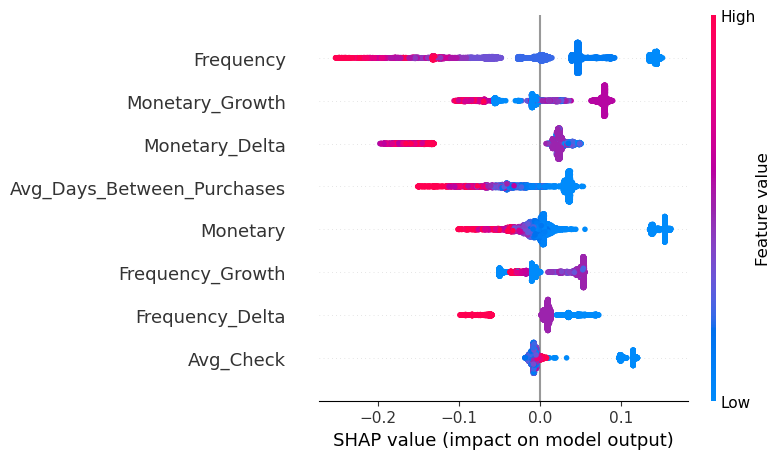

In [2]:
# =====================================================
# GLOBAL SHAP IMPORTANCE
# =====================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

**Key Findings**

SHAP-анализ подтверждает результаты feature importance и показывает, что вероятность оттока определяется преимущественно поведенческими и временными признаками. Наибольшее влияние на прогноз оказывают Frequency, Monetary Growth, Monetary Delta, Frequency Growth и средний интервал между покупками.

Высокая частота покупок и положительная динамика Frequency Growth систематически снижают churn probability, тогда как снижение темпов роста выручки, ухудшение Monetary Delta и увеличение интервалов между транзакциями смещают прогноз в сторону высокого риска оттока.

Результаты показывают, что модель реагирует не столько на текущий уровень клиентской активности, сколько на изменение пользовательского поведения относительно собственной исторической нормы. Иными словами, ключевым индикатором риска выступает не низкая активность сама по себе, а признаки постепенной деградации вовлечённости.

Это подтверждает гипотезу о том, что churn представляет собой процесс постепенного ослабления покупательского поведения, который начинается задолго до фактического прекращения покупок. Снижение интенсивности транзакций формирует ранний сигнал потери клиента раньше, чем пользователь переходит в стадию At Risk или Churn.

Для retention-стратегии приоритетным объектом мониторинга должны стать не статические RFM-показатели, а изменения частоты покупок, выручки и покупательского ритма во времени. Наибольшую ценность представляют механизмы раннего выявления негативных поведенческие тенденции до наступления фактического оттока.

Использование динамических поведенческих сигналов в CRM-триггерах позволяет выявлять клиентов на стадии формирования churn-risk, повышать своевременность retention-интервенций и снижать объём потенциальной выручки, теряемой вследствие поздней реакции на ухудшение клиентского поведения.

## Key Drivers of Customer Churn Risk (Global Feature Importance)

На предыдущем этапе были исследованы механизмы влияния отдельных признаков на вероятность оттока и определены направления их воздействия на churn-risk. Однако для принятия продуктовых решений важно не только понимать характер влияния факторов, но и оценить их относительную значимость в общей логике модели.

Цель анализа — определить, какие группы признаков формируют основной predictive signal при прогнозировании оттока и какие аспекты клиентского поведения обладают наибольшей объясняющей способностью. Дополнительно проверяется гипотеза о том, что динамические behavioral features превосходят статические клиентские характеристики по вкладу в качество прогнозирования.

Для анализа используется агрегированная SHAP importance, отражающая средний абсолютный вклад каждого признака в прогноз модели по всей тестовой выборке. В отличие от традиционной feature importance, данный подход позволяет оценить фактическое влияние признаков на итоговые предсказания независимо от внутренней структуры алгоритма.

Если наибольший вклад будут демонстрировать показатели изменения покупательской активности и монетизации, это подтвердит, что риск оттока формируется преимущественно через ухудшение пользовательского поведения во времени. В таком случае раннее выявление негативных поведенческих тенденций может стать ключевым элементом проактивной retention-стратегии и системы предотвращения оттока клиентов.

Для оценки относительной значимости факторов прогнозирования построим агрегированное распределение SHAP importance по всем признакам модели.

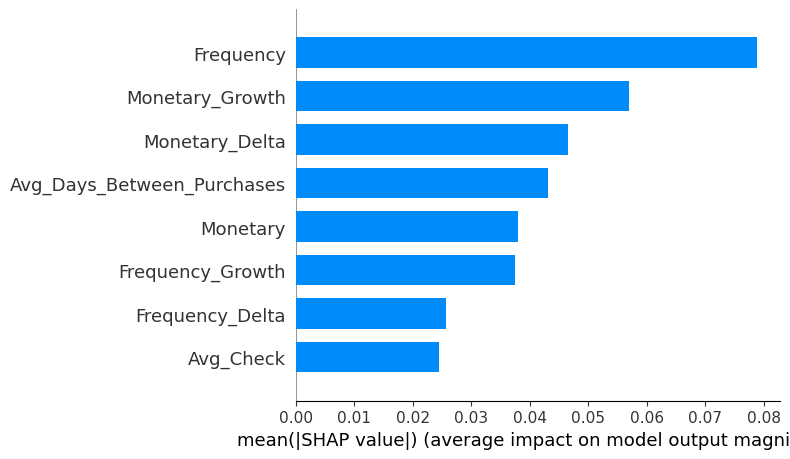

In [3]:
# =====================================================
# SHAP BAR PLOT
# =====================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type='bar'
)

**Key Findings**

Агрегированная SHAP importance показывает, что наибольший вклад в прогнозирование оттока вносят Frequency (0.079), Monetary Growth (0.057), Monetary Delta (0.047) и Avg Days Between Purchases (0.043). Существенная часть предиктивного сигнала сосредоточена в признаках, отражающих изменение покупательского поведения и интенсивности взаимодействия с продуктом.

При этом Frequency остаётся наиболее значимым фактором модели, подтверждая ключевую роль регулярности покупок в формировании долгосрочного удержания клиентов.

Результаты показывают, что риск оттока определяется одновременно текущим уровнем клиентской активности и динамикой её изменения во времени. Модель учитывает не только то, насколько ценен и активен клиент сегодня, но и признаки ухудшения его покупательского поведения относительно предыдущих периодов.

Высокая значимость Monetary Growth, Monetary Delta и Frequency Growth подтверждает гипотезу о том, что снижение customer value и покупательской интенсивности является одним из наиболее ранних сигналов будущего оттока.

Для эффективного управления retention недостаточно отслеживать клиентов с низкими абсолютными значениями RFM-метрик. Более высокий бизнес-потенциал имеют системы раннего обнаружения негативных поведенческих тенденций — сокращения частоты покупок, замедления роста выручки и увеличения интервалов между транзакциями.

Использование динамических поведенческих сигналов в CRM-приоритизации позволяет выявлять клиентов на стадии формирования churn-risk, повышать своевременность retention-интервенций и снижать объём revenue-at-risk за счёт более раннего воздействия на проблемные сегменты.

## Individual Customer Churn Risk Explanation (Case-Level SHAP Analysis)

На предыдущих этапах были определены ключевые драйверы оттока на уровне всей клиентской базы и оценена их относительная значимость в прогнозной модели. Однако агрегированные результаты не позволяют понять, каким образом конкретные поведенческие факторы формируют churn-risk отдельного клиента и почему модель принимает то или иное решение.

Цель анализа — декомпозировать индивидуальный прогноз оттока и определить, какие признаки повышают или снижают вероятность ухода конкретного пользователя. Дополнительно проверяется гипотеза о том, что даже при одинаковом итоговом уровне риска различные клиенты могут иметь принципиально разные поведенческие причины потенциального оттока.

Для интерпретации используется локальное SHAP-объяснение, позволяющее разложить прогноз модели на вклад отдельных признаков. Такой подход делает решение модели прозрачным и позволяет связать вероятность оттока с конкретными изменениями в покупательском поведении клиента, а не только с итоговым скоринговым значением.

Практическая ценность анализа заключается в возможности перехода от сегментного управления к персонализированным retention-действиям. Понимание индивидуальных драйверов риска позволяет адаптировать коммуникации под конкретные причины ухудшения поведения пользователя и формировать более точечные сценарии удержания.

Рассмотрим структуру прогноза модели для отдельного клиента и определим факторы, которые внесли наибольший вклад в формирование его churn-risk.

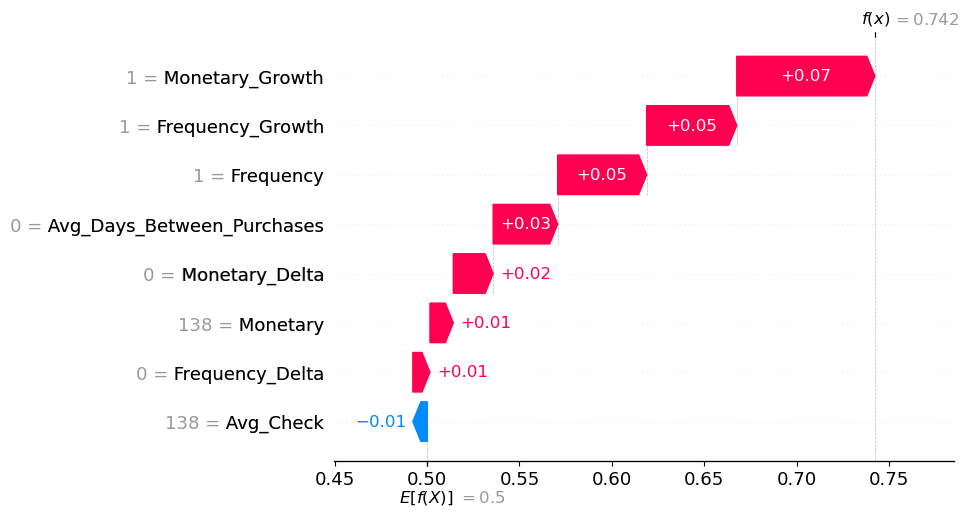

In [4]:
# =====================================================
# SINGLE CUSTOMER EXPLANATION
# =====================================================

customer_idx = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:, :, 1][customer_idx],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[customer_idx],
        feature_names=X_test.columns
    )
)

**Key Findings**

Для рассматриваемого клиента прогноз оттока формируется преимущественно за счёт положительного вклада Monetary Growth (+0.075), Frequency Growth (+0.049), Frequency (+0.048) и Avg Days Between Purchases (+0.035). Отрицательное влияние оказывает только Avg Check (-0.008), однако его вклад недостаточен для компенсации совокупного роста churn-risk. В результате большинство признаков смещают прогноз модели в сторону повышенной вероятности перехода клиента в At Risk или Churn сегмент.

Локальное SHAP-объяснение показывает, что модель оценивает риск не по отдельным метрикам, а по совокупному поведенческому профилю клиента. Несмотря на наличие недавней покупательской активности, клиент характеризуется низкой исторической вовлечённостью и ограниченной транзакционной историей, что делает его профиль схожим с пользователями, которые впоследствии прекращают регулярные покупки.

Дополнительно анализ подтверждает, что локальная логика модели может отличаться от глобальных закономерностей. Один и тот же признак способен оказывать различное влияние на прогноз в зависимости от сочетания с другими характеристиками поведения клиента.

Данный пример демонстрирует, что риск оттока определяется не отдельными значениями RFM-показателей, а комплексным behavioral профилем пользователя. Даже наличие отдельных позитивных сигналов не гарантирует низкий churn-risk, если общая структура поведения соответствует паттернам клиентов с последующим снижением активности.

Практическая ценность подобных объяснений заключается в возможности перехода от массовых retention-кампаний к персонализированным сценариям удержания. Использование индивидуальных churn drivers позволяет не только выявлять клиентов с высоким риском ухода, но и понимать конкретные причины формирования риска, что повышает точность CRM-коммуникаций и эффективность retention-инвестиций.

# Risk-Based Customer Segmentation for Retention Prioritization

На предыдущих этапах была построена модель прогнозирования оттока и исследованы факторы, формирующие churn-risk на уровне всей клиентской базы и отдельных пользователей. Следующим шагом является перевод вероятностей модели в практический инструмент управления retention-активностями и CRM-коммуникациями.

Цель анализа — определить, насколько неоднородна клиентская база с точки зрения риска оттока и существуют ли существенные различия между сегментами по уровню покупательской активности и коммерческой ценности. Дополнительно проверяется гипотеза о том, что клиенты с высоким churn-risk формируют отдельный поведенческий профиль, требующий специализированных retention-механик.

Для анализа пользователи группируются по предсказанной вероятности оттока в пять risk-сегментов: от Very Low Risk до Critical Risk. Для каждого сегмента рассчитываются средние показатели churn probability, выручки, покупательской частоты и среднего чека. Такой подход позволяет перейти от индивидуальных прогнозов к управляемой системе приоритизации клиентской базы.

Если сегменты с высоким риском будут одновременно характеризоваться существенным вкладом в выручку, это может указывать на наличие значительного revenue-at-risk и необходимости активных retention-инвестиций. Напротив, концентрация низкоценных клиентов в высокорисковых сегментах будет свидетельствовать о целесообразности более избирательного распределения маркетинговых ресурсов.

Для оценки структуры клиентской базы и формирования risk-based сегментации проанализируем распределение пользователей по уровням прогнозируемого churn-risk и сравним ключевые бизнес-метрики между сегментами.

In [5]:
# =====================================================
# TEST RESULTS
# =====================================================

results = test_df.copy()

results['Churn_Probability'] = pred_proba

# =====================================================
# RISK SEGMENTS
# =====================================================

results['Risk_Segment'] = pd.qcut(
    results['Churn_Probability'],
    q=5,
    labels=[
        'Very Low Risk',
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Critical Risk'
    ]
)

# =====================================================
# SEGMENT DISTRIBUTION
# =====================================================

segment_summary = (
    results.groupby('Risk_Segment', observed=True)
    .agg({
        'card': 'count',
        'Churn_Probability': 'mean',
        'Monetary': 'mean',
        'Frequency': 'mean',
        'Avg_Check': 'mean'
    })
    .round(2)
)

segment_summary.columns = [
    'Customers',
    'Avg_Churn_Probability',
    'Avg_Monetary',
    'Avg_Frequency',
    'Avg_Check'
]

print("="*60)
print("5-level risk segmentation")
print("="*60)

print(segment_summary)

5-level risk segmentation
               Customers  Avg_Churn_Probability  Avg_Monetary  Avg_Frequency  Avg_Check
Risk_Segment                                                                           
Very Low Risk        957                   0.05       6621.34           6.99     918.77
Low Risk             956                   0.45       2388.02           2.70    1015.43
Medium Risk          957                   0.64       1727.67           1.80    1069.55
High Risk            955                   0.74        964.04           1.00     964.04
Critical Risk        956                   0.92         66.12           0.17      66.12


**Key Findings**

Модель формирует хорошо разделённую risk-структуру клиентской базы: по мере роста прогнозируемой вероятности оттока наблюдается последовательное снижение ключевых показателей покупательской активности и монетизации.

Средняя частота покупок сокращается с 6.99 транзакций в сегменте Very Low Risk до 0.17 в сегменте Critical Risk, а средняя выручка на клиента снижается более чем в 100 раз — с 6 621 до 66 денежных единиц. Такая монотонная динамика подтверждает высокую поведенческую согласованность сформированных risk-сегментов.

При этом рост churn probability сопровождается не только ухудшением retention-потенциала, но и снижением текущей коммерческой ценности клиентов, что свидетельствует о тесной взаимосвязи между деградацией вовлечённости и сокращением экономического вклада пользователей.

**Insights**

Полученные результаты показывают, что вероятность оттока отражает не изолированный риск ухода клиента, а общий процесс постепенного ослабления customer engagement.

Клиенты из сегментов High Risk и Critical Risk уже демонстрируют признаки существенной деградации покупательского поведения: снижение частоты взаимодействий, сокращение объёма расходов и ослабление транзакционной активности. Напротив, пользователи из сегмента Very Low Risk формируют наиболее устойчивую и экономически значимую часть клиентской базы.

Важно отметить, что наиболее высокий риск оттока концентрируется преимущественно среди низкоценных клиентов. Это означает, что высокий churn probability сам по себе не является достаточным основанием для retention-инвестиций и должен рассматриваться совместно с показателями клиентской ценности.

**Business Interpretation**

С точки зрения бизнеса результаты подтверждают необходимость перехода от бинарного подхода «удерживать всех клиентов с высоким риском» к многофакторной системе приоритизации.

Наиболее перспективными объектами для retention-активностей являются пользователи, которые одновременно обладают повышенным риском оттока и сохраняют значимый уровень выручки. В противном случае стоимость удержания может превышать потенциальный экономический эффект от сохранения клиента.

Таким образом, churn probability выступает первым уровнем фильтрации клиентской базы, который впоследствии должен дополняться оценкой customer value и потенциального revenue-at-risk.

**Strategic Implication**

Построенная risk-сегментация создаёт основу для формирования риск-ориентированной CRM-стратегии.

Сегменты Very Low Risk и Low Risk могут рассматриваться как аудитория для программ лояльности и развития ценности клиента, тогда как сегменты High Risk и Critical Risk требуют отдельных сценариев удержания и реактивации. Одновременно результаты показывают необходимость дальнейшего анализа коммерческой значимости каждого риск-сегмента для определения клиентов, потеря которых создаёт максимальный финансовый риск для бизнеса.

Следующим шагом целесообразно объединить churn probability с показателями клиентской ценности и оценкой потенциальных потерь выручки, сформировав полноценную систему retention prioritization.

## Customer Value and Risk Prioritization Matrix

На предыдущем этапе клиентская база была сегментирована по вероятности оттока, что позволило оценить распределение churn-risk между пользователями. Однако риск сам по себе не определяет бизнес-приоритетность клиента: потеря низкоценного пользователя и потеря крупного клиента оказывают принципиально разное влияние на выручку компании.

Цель анализа — объединить оценку вероятности оттока и клиентской ценности в единую систему приоритизации retention-активностей. Дополнительно проверяется гипотеза о том, что наибольший бизнес-риск формируют не все клиенты с высоким churn probability, а пользователи, одновременно обладающие высокой коммерческой ценностью и повышенной вероятностью ухода.

Для анализа клиентская база сегментируется по двум измерениям: уровню текущей ценности (Value Segments) и прогнозируемому риску оттока (Risk Segments). Комбинация этих признаков формирует стратегическую матрицу сегментации, позволяющую оценить размер сегмента, уровень риска, покупательскую активность и потенциальную значимость для бизнеса. Такой подход соответствует принципам risk-adjusted customer management, где решения принимаются не только на основе вероятности события, но и с учетом его экономических последствий.

Ожидается, что наиболее критичными для бизнеса окажутся сегменты с высокой выручкой и одновременно повышенным риском оттока. Именно такие группы формируют основной объём потенциального revenue-at-risk и являются первоочередными кандидатами для персонализированных retention-интервенций. Напротив, сегменты с низкой ценностью и высоким риском могут демонстрировать ограниченную экономическую целесообразность активного удержания.

Для выявления наиболее значимых клиентских сегментов объединим показатели churn-risk и customer value в единую стратегическую матрицу и сравним ключевые бизнес-метрики между сформированными группами.

In [6]:
# =====================================================
# CUSTOMER VALUE SEGMENTS
# =====================================================

results['Value_Segment'] = pd.qcut(
    results['Monetary'],
    q=3,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value'
    ]
)

# =====================================================
# STRATEGIC SEGMENTS
# =====================================================

results['Strategic_Segment'] = (
    results['Value_Segment'].astype(str)
    + ' | '
    + results['Risk_Segment'].astype(str)
)

# =====================================================
# STRATEGIC SUMMARY
# =====================================================

strategic_summary = (
    results.groupby('Strategic_Segment')
    .agg({
        'card': 'count',
        'Churn_Probability': 'mean',
        'Monetary': 'mean',
        'Frequency': 'mean'
    })
    .round(2)
    .sort_values(
        'Monetary',
        ascending=False
    )
)

strategic_summary.columns = [
    'Customers',
    'Avg_Churn_Probability',
    'Avg_Monetary',
    'Avg_Frequency'
]


print("="*60)
print('STRATEGIC SUMMARY')
print("="*60)

print(strategic_summary)

STRATEGIC SUMMARY
                              Customers  Avg_Churn_Probability  Avg_Monetary  Avg_Frequency
Strategic_Segment                                                                          
High Value | Very Low Risk          727                   0.06       8377.71           8.36
High Value | Low Risk               445                   0.43       4055.16           3.68
High Value | Medium Risk            278                   0.62       3485.41           2.10
High Value | High Risk              137                   0.74       2517.34           1.00
High Value | Critical Risk            7                   0.76       2078.14           1.00
Medium Value | Medium Risk          527                   0.65       1199.93           1.73
Medium Value | Very Low Risk        194                   0.02       1187.29           2.78
Medium Value | Low Risk             369                   0.46       1160.77           2.05
Medium Value | Critical Risk         22                   0.77

**Key Findings**

Стратегическая сегментация показала, что высокий churn-risk распределён между клиентами с принципиально разной коммерческой ценностью. Наиболее крупный сегмент базы — High Value | Very Low Risk (727 клиентов, средняя выручка 8 378), тогда как основная концентрация критического риска приходится на Low Value | Critical Risk (927 клиентов, средняя выручка 29). Одновременно существует ограниченная, но экономически значимая группа клиентов High Value | High/Critical Risk (144 клиента), генерирующая более 2 500 средней выручки на пользователя при вероятности оттока выше 0.74.

Результаты подтверждают, что churn-risk сам по себе не отражает масштаб бизнес-угрозы. Большинство клиентов с максимальным риском ухода уже обладают низкой экономической ценностью и формируют ограниченный объём потенциальных потерь. Основной revenue-at-risk концентрируется в сравнительно небольшой группе высокоценных клиентов, демонстрирующих признаки ухудшения поведения. Именно этот сегмент создаёт наибольший разрыв между потенциальной потерей выручки и текущим уровнем удержания.

Возможной причиной формирования сегмента High Value | High Risk является постепенная деградация покупательской активности ранее лояльных клиентов: снижение частоты покупок, увеличение интервалов между транзакциями или ослабление потребности в регулярных покупках. Предположительно именно эти пользователи находятся на ранней стадии ухода и ещё сохраняют потенциал для удержания.

Результаты показывают необходимость перехода от risk-based к value-adjusted retention-стратегии. Приоритизация CRM-коммуникаций должна учитывать не только вероятность оттока, но и ожидаемый финансовый ущерб от потери клиента. Основной объект retention-инвестиций — высокоценные клиенты с повышенным churn-risk, а не весь высокорисковый сегмент целиком.

Приоритетными направлениями дальнейшего анализа и оптимизации являются: 

1. В первую очередь запустить персонализированные retention-кампании для сегментов High Value | High Risk и High Value | Critical Risk.
2. Построить модель Revenue-at-Risk для количественной оценки потенциальных финансовых потерь по каждому сегменту.
3. Для сегмента Low Value | Critical Risk использовать низкозатратные автоматизированные сценарии реактивации без существенных retention-инвестиций.
4. Внедрить мониторинг поведенческой деградации среди высокоценных клиентов как систему раннего предупреждения churn.

Фокусирование retention-бюджета на сегментах с максимальным revenue-at-risk позволяет повысить эффективность CRM-коммуникаций, снизить потери выручки от ухода ценных клиентов и увеличить ROI удерживающих активностей без пропорционального роста маркетинговых затрат.

## Customer Risk–Value Matrix

На предыдущем этапе клиенты были сегментированы одновременно по вероятности оттока и текущей коммерческой ценности, что позволило выделить приоритетные группы для retention-активностей. Однако агрегированные сегменты скрывают индивидуальное распределение клиентов внутри каждой категории и не позволяют оценить концентрацию риска по всей клиентской базе.

Цель анализа — исследовать взаимосвязь между клиентской ценностью и прогнозируемым риском оттока, а также определить, насколько churn-risk распределён среди различных уровней монетизации. Дополнительно проверяется гипотеза о том, что высокий риск ухода присутствует не только среди низкоценных клиентов, но и внутри отдельных групп, формирующих значимую долю выручки бизнеса.

Для анализа используется матрица «ценность–риск», где каждый клиент рассматривается как отдельное наблюдение. По одной оси отображается накопленная клиентская ценность (Monetary), по другой — прогнозируемая вероятность оттока. Такой подход позволяет одновременно оценить revenue exposure и retention risk, а также выявить потенциальные точки концентрации будущих потерь выручки.

Особый интерес представляют клиенты, сочетающие высокий вклад в выручку и повышенную вероятность оттока. Именно эта группа обычно формирует основной экономический риск для бизнеса и требует приоритетного внимания со стороны CRM, программ лояльности и механизмов персонализированного удержания.

Построим карту распределения клиентов по уровням ценности и прогнозируемого риска оттока.

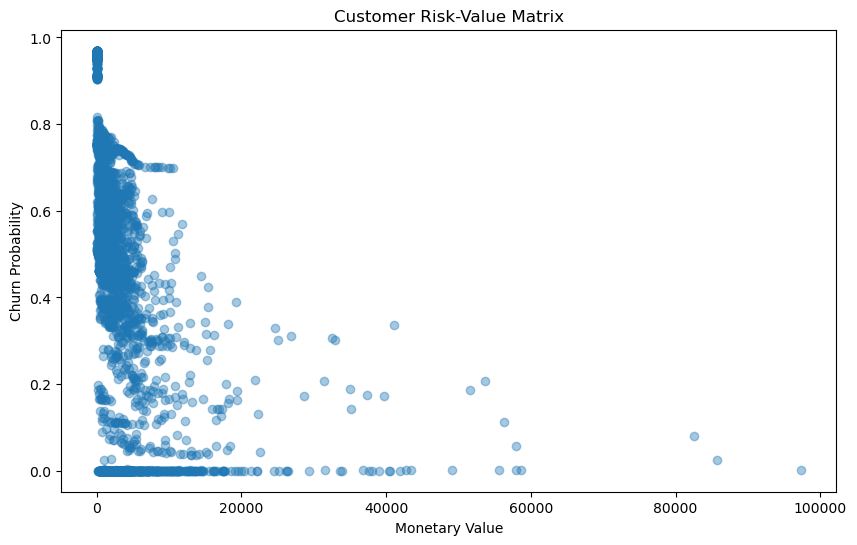

In [7]:
# =====================================================
# CUSTOMER RISK-VALUE MATRIX
# =====================================================

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    results['Monetary'],
    results['Churn_Probability'],
    alpha=0.4
)

plt.xlabel('Monetary Value')
plt.ylabel('Churn Probability')
plt.title('Customer Risk-Value Matrix')

plt.show()

**Key Findings**

Матрица Risk–Value показывает выраженную концентрацию клиентов в зоне низкой накопленной ценности, при этом уровень прогнозируемого churn-risk внутри этой группы варьируется от минимальных до критически высоких значений. Одновременно наблюдается отдельная группа высокоценных клиентов (Monetary > 20–30 тыс.), для которых вероятность оттока в большинстве случаев остается низкой или умеренной. Тем не менее среди клиентов с существенным вкладом в выручку присутствуют отдельные наблюдения с повышенным churn-risk, формирующие потенциально непропорционально высокий revenue-at-risk.

Риск оттока распределен по клиентской базе неравномерно и не ограничивается низкоценовыми сегментами. Большинство клиентов с высоким churn-risk обладают относительно низкой коммерческой ценностью, поэтому их массовое удержание может иметь ограниченную экономическую эффективность. Основной бизнес-риск сосредоточен в небольшой группе клиентов, которые одновременно генерируют значимую часть выручки и демонстрируют признаки вероятного ухода. Потеря даже ограниченного числа таких пользователей способна оказать заметно большее влияние на выручку, чем отток большого количества низкоценных клиентов. Это подтверждает необходимость перехода от управления churn к управлению revenue-at-risk.

Возможной причиной низкого churn-risk среди наиболее ценных клиентов является более высокая вовлеченность и сформированная покупательская привычка. Наличие отдельных высокоценных клиентов с повышенной вероятностью оттока предположительно связано с ухудшением частоты покупок, увеличением интервалов между транзакциями или снижением объема заказов, которые модель интерпретирует как ранние признаки деградации поведения.

Retention-стратегия не должна строиться исключительно вокруг вероятности оттока. Приоритизация CRM-инвестиций должна учитывать одновременно риск ухода и экономическую ценность клиента, поскольку именно сегмент high-value / high-risk формирует основной источник потенциальных потерь выручки.

Приоритетными направлениями дальнейшего анализа и оптимизации являются:

1. Выделить сегмент high-value / high-risk в отдельный retention-пул с персонализированными коммуникациями и повышенным уровнем CRM-поддержки.  
2. Внедрить регулярный мониторинг revenue-at-risk для оценки потенциальных финансовых потерь на уровне клиента.  
3. Снизить интенсивность удерживающих активностей для low-value / high-risk клиентов, где ожидаемый ROI ограничен.  
4. Использовать churn scoring как триггер раннего вмешательства до фактического перехода клиента в At Risk или Churn стадии.  

Фокусирование retention-бюджета на клиентах с максимальным revenue-at-risk позволит повысить эффективность CRM-коммуникаций, снизить потенциальные потери выручки и увеличить ROI retention-программ за счет более точного распределения ресурсов между сегментами клиентской базы.

## Revenue-at-Risk Prioritization Based on Expected Future Value

На предыдущих этапах была построена модель прогнозирования оттока, выделены клиентские риск-сегменты и определены группы, требующие приоритетного внимания со стороны retention-механик. Однако вероятность оттока сама по себе не позволяет оценить потенциальные финансовые последствия ухода клиентов.

Цель анализа — определить клиентов, формирующих наибольший ожидаемый риск потери выручки, и перейти от оценки churn probability к оценке бизнес-воздействия оттока. Дополнительно проверяется гипотеза о том, что наиболее критичный риск для бизнеса сосредоточен не среди самых вероятных кандидатов на отток, а среди клиентов, одновременно обладающих высокой коммерческой ценностью и повышенной вероятностью ухода.

Для анализа рассчитывается ожидаемая будущая ценность клиента с учётом текущего уровня монетизации и динамики её изменения. Далее прогнозируемая выручка корректируется на вероятность оттока, что позволяет получить показатель Expected Revenue Loss — ожидаемый объём выручки, который бизнес рискует потерять при сохранении текущих поведенческих трендов.

Такой подход позволяет ранжировать клиентскую базу не по уровню риска как таковому, а по потенциальному финансовому ущербу. В результате становится возможным более эффективно распределять retention-бюджет, концентрируя ресурсы на клиентах, где потенциальный возврат от удержания максимален.

Рассчитаем ожидаемые потери выручки и выделим клиентов, формирующих наибольший объём revenue at risk.

In [8]:
# =====================================================
# EXPECTED FUTURE REVENUE
# =====================================================

results['Expected_Future_Revenue'] = (
    results['Monetary']
    *
    (1 + results['Monetary_Growth'].clip(-0.5, 1.5))
)

# =====================================================
# EXPECTED REVENUE LOSS
# =====================================================

results['Expected_Revenue_Loss'] = (
    results['Expected_Future_Revenue']
    *
    results['Churn_Probability']
)

# =====================================================
# TOP REVENUE AT RISK
# =====================================================

top_risk_customers = (
    results.sort_values(
        'Expected_Revenue_Loss',
        ascending=False
    )
    [[
        'card',
        'Lifecycle_Stage',
        'Risk_Segment',
        'Monetary',
        'Monetary_Growth',
        'Churn_Probability',
        'Expected_Revenue_Loss'
    ]]
    .head(20)
)

print("="*60)
print('TOP RISK CUSTOMERS')
print("="*60)

print(top_risk_customers)

TOP RISK CUSTOMERS
                card Lifecycle_Stage   Risk_Segment  Monetary  Monetary_Growth  Churn_Probability  Expected_Revenue_Loss
21964  2000200224594           Loyal       Low Risk   41142.0         1.000000           0.335410           27598.874239
86     2000200150411           Loyal  Very Low Risk   53621.0         0.984504           0.207399           22069.513578
20056  2000200220619           Loyal  Very Low Risk   32479.0         1.000000           0.307112           19949.358769
15402  2000200208259           Loyal  Very Low Risk   32869.0         1.000000           0.302855           19909.062407
8007   2000200186205           Loyal  Very Low Risk   51631.0         0.821143           0.187170           17599.156989
14419  2000200205975           Loyal  Very Low Risk   26833.0         1.000000           0.311077           16694.241384
16691  2000200211303           Loyal       Low Risk   24689.0         1.000000           0.330371           16313.038470
21940  200020

**Key Findings**

Анализ ожидаемых потерь выручки показывает, что наибольший финансовый риск для бизнеса формируется не клиентами из сегмента Critical Risk, а высокоценными клиентами с крупным объёмом покупок и умеренной вероятностью оттока.

Среди клиентов с максимальным Expected Revenue Loss преобладают пользователи из Lifecycle-сегментов Loyal и Active. Несмотря на относительно невысокие значения churn probability (0.17–0.42 для значительной части наблюдений), высокий уровень монетизации приводит к существенному ожидаемому объёму потенциально утрачиваемой выручки.

**Insights**

Результаты показывают, что вероятность оттока и бизнес-риск не являются эквивалентными понятиями. Клиенты с самым высоким churn-risk часто обладают низкой коммерческой ценностью, тогда как основные финансовые потери концентрируются среди клиентов с высокой исторической выручкой.

Это означает, что стратегия удержания, основанная исключительно на прогнозируемой вероятности ухода, может приводить к неэффективному распределению CRM-ресурсов. Для бизнеса важнее приоритизировать клиентов по ожидаемому экономическому ущербу, а не по риску оттока в изоляции от их ценности.

**Hypothesis**

Возможной причиной подобного распределения является наличие группы клиентов с высокой покупательской активностью и значительным вкладом в выручку, у которых уже появляются ранние признаки ухудшения поведения, однако деградация ещё не достигла уровня, характерного для сегментов At Risk или Churn.

Предположительно именно эта категория клиентов представляет наиболее привлекательную точку приложения retention-инициатив, поскольку обладает одновременно высоким потенциалом сохранённой выручки и достаточным запасом времени для вмешательства.

**Strategic Implication**

Ключевым объектом управления должны становиться не клиенты с максимальной вероятностью оттока, а клиенты с максимальным значением Revenue at Risk.

Приоритизация retention-активностей через ожидаемые финансовые потери позволяет перейти от массового удержания к value-based CRM-модели и повысить эффективность инвестиций в удержание клиентской базы.

**Prioritized Actions**

1. Сформировать отдельный сегмент Revenue at Risk для клиентов с максимальным Expected Revenue Loss.   
2. Запускать персонализированные retention-кампании прежде всего для высокоценных клиентов с признаками ухудшения поведения.  
3. Использовать Revenue at Risk как дополнительный KPI при планировании CRM-бюджета и распределении маркетинговых ресурсов.  
4. Регулярно мониторить изменение объёма выручки, находящейся под риском, как опережающий индикатор будущих потерь бизнеса.  
  
**Expected Impact**

Фокус на клиентах с максимальным Revenue at Risk позволяет снизить потенциальные потери выручки без существенного увеличения затрат на удержание, повысить эффективность CRM-коммуникаций и увеличить отдачу от retention-инвестиций за счёт концентрации усилий на наиболее экономически значимых клиентах.

## Revenue Risk Portfolio Analysis

На предыдущем этапе были выявлены отдельные клиенты, формирующие наибольший ожидаемый риск потери выручки. Однако для принятия управленческих решений важно понимать не только индивидуальные случаи, но и структуру риска на уровне всей клиентской базы.

Цель анализа — определить, как потенциальные потери выручки распределяются между сегментами риска и какие группы клиентов формируют основную долю revenue at risk. Дополнительно проверяется гипотеза о том, что финансовый риск концентрируется в ограниченном числе сегментов, что позволяет существенно повысить эффективность retention-инвестиций за счёт приоритизации наиболее значимых групп.

Для анализа клиентская база агрегируется по ранее сформированным risk-сегментам. Для каждого сегмента рассчитываются численность клиентов, совокупная ожидаемая выручка и суммарный объём потенциальных потерь, скорректированный на вероятность оттока. Такой подход позволяет перейти от оценки индивидуального риска к управлению риском на уровне клиентского портфеля.

Особый интерес представляет соотношение между размером сегмента, его вкладом в выручку и объёмом revenue at risk. Если значительная часть потенциальных потерь сосредоточена в ограниченном числе сегментов, это может указывать на возможность точечного перераспределения CRM-ресурсов с более высокой ожидаемой отдачей.

Для оценки структуры финансового риска проанализируем распределение ожидаемых потерь выручки по всем сегментам клиентского портфеля.

In [9]:
# =====================================================
# RISK PORTFOLIO
# =====================================================

portfolio_summary = (
    results.groupby(
        'Risk_Segment',
        observed=True
    )
    .agg({
        'card': 'count',
        'Expected_Revenue_Loss': 'sum',
        'Expected_Future_Revenue': 'sum'
    })
    .round(2)
)

portfolio_summary.columns = [
    'Customers',
    'Total_Revenue_At_Risk',
    'Total_Expected_Revenue'
]

#print("\n")
print("="*60)
print("RISK PORTFOLIO")
print("="*60)

print(portfolio_summary)

RISK PORTFOLIO
               Customers  Total_Revenue_At_Risk  Total_Expected_Revenue
Risk_Segment                                                           
Very Low Risk        957              787268.27             13636511.08
Low Risk             956             1645877.38              3872310.45
Medium Risk          957             2049121.71              3215763.51
High Risk            955             1353762.22              1834352.39
Critical Risk        956               76218.81               100138.36


**Key Findings**

Анализ риск-портфеля показал, что наибольший объём потенциально теряемой выручки сосредоточен не в сегменте Critical Risk, а в сегментах Medium Risk и Low Risk. Суммарный объём ожидаемых потерь составляет:  

Medium Risk — 2.05 млн  
Low Risk — 1.65 млн  
High Risk — 1.35 млн  
Very Low Risk — 0.79 млн  
Critical Risk — 0.08 млн  

При этом сегмент Critical Risk содержит сопоставимое количество клиентов (956), однако формирует менее 2% общего объёма revenue at risk вследствие крайне низкой клиентской ценности.

Полученные результаты показывают, что вероятность оттока и бизнес-ценность клиента не являются эквивалентными приоритетами для retention-стратегии. Наибольший финансовый риск формируют не клиенты с максимальной вероятностью ухода, а клиенты со средним уровнем риска и существенным вкладом в выручку. Именно здесь одновременно присутствуют два фактора: достаточно высокая вероятность потери и значимый денежный потенциал.

С точки зрения unit-экономики потеря одного клиента из сегмента Medium Risk может оказывать большее влияние на будущую выручку, чем потеря нескольких клиентов из сегмента Critical Risk. Это означает, что оптимизация CRM только по churn probability приводит к неоптимальному распределению retention-бюджета.

Возможной причиной такой структуры является различие жизненного цикла клиентских сегментов. Critical Risk преимущественно состоит из клиентов с уже деградировавшей активностью и низкой ценностью, тогда как Medium и Low Risk включают значительную долю действующих покупателей, демонстрирующих первые признаки снижения вовлеченности. Предположительно именно на этой стадии поведенческие изменения еще обратимы и могут быть скорректированы CRM-механиками.

Retention-система должна приоритизировать клиентов по ожидаемому финансовому эффекту сохранения, а не только по вероятности оттока. В качестве ключевой метрики для управления риском целесообразно использовать Revenue at Risk, объединяющую churn propensity и клиентскую ценность в единый показатель бизнес-приоритета.

Приоритетными направлениями дальнейшего анализа и оптимизации являются:

1. Сформировать CRM-приоритет на сегменты Medium Risk и Low Risk с высоким Revenue at Risk.  
2. Внедрить ранние retention-механизмы для клиентов с признаками ухудшения поведенческой динамики (Frequency Growth, Monetary Growth, Purchase Cadence) до перехода в High Risk и Critical Risk.   
3. Использовать Revenue at Risk как критерий распределения маркетингового бюджета и персонализированных удерживающих коммуникаций.  
4. Построить мониторинг объёма выручки под риском по сегментам как отдельный KPI retention-программы.  

Смещение фокуса с максимального churn-risk на максимальный Revenue at Risk позволяет концентрировать ресурсы на клиентах с наибольшим потенциальным вкладом в выручку. Это должно повысить эффективность retention-кампаний, увеличить объём сохранённой выручки и улучшить ROI CRM-активностей без пропорционального роста затрат на удержание.

## Revenue Risk Portfolio Mapping

На предыдущих этапах были определены уровни churn-risk клиентов и рассчитан ожидаемый объем выручки, находящейся под риском потери. Однако агрегированные показатели не позволяют оценить структуру риска на уровне всей клиентской базы и определить, какие группы клиентов формируют наибольшую концентрацию потенциальных потерь.

Цель анализа — исследовать взаимосвязь между прогнозируемой будущей ценностью клиента и вероятностью его оттока. Ключевой аналитический вопрос заключается в том, сосредоточен ли риск потери выручки среди низкоценных клиентов или значимая часть revenue-at-risk формируется за счет клиентов с высоким экономическим потенциалом.

Для анализа используется двумерное представление клиентского портфеля, где каждый клиент одновременно оценивается по двум измерениям: ожидаемой будущей выручке (Expected Future Revenue) и вероятности оттока (Churn Probability). Такой подход позволяет перейти от сегментации по отдельным метрикам к оценке совокупного бизнес-риска и выявлению приоритетных зон для retention-инвестиций.

Особый интерес представляют клиенты, находящиеся в области высокой будущей ценности и повышенного риска ухода. Именно этот сегмент обычно формирует наибольший объем потенциально предотвращаемых потерь и обеспечивает максимальную отдачу от персонализированных программ удержания.

Для оценки распределения клиентского портфеля по уровням ценности и риска визуализируем матрицу Revenue Risk Portfolio.

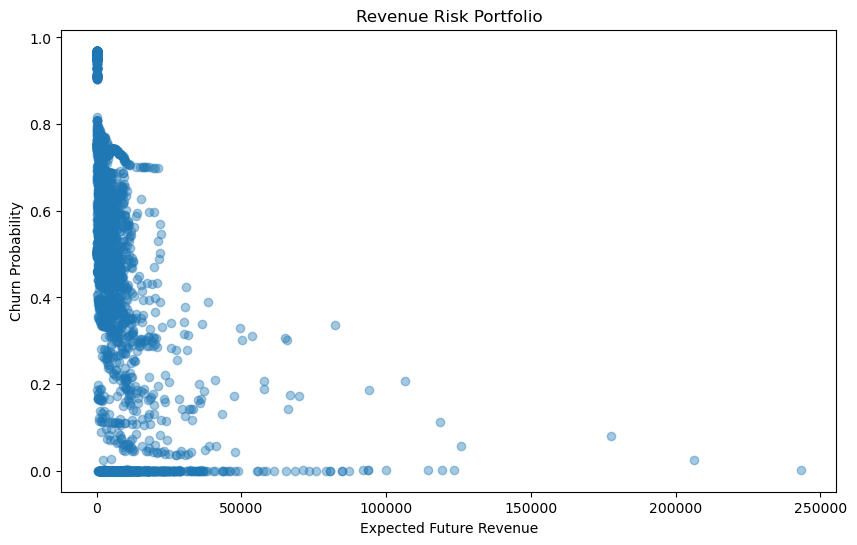

In [10]:
# =====================================================
# RISK-VALUE MATRIX
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    results['Expected_Future_Revenue'],
    results['Churn_Probability'],
    alpha=0.4
)

plt.xlabel('Expected Future Revenue')
plt.ylabel('Churn Probability')

plt.title('Revenue Risk Portfolio')

plt.show()

**Key Findings**

Матрица Revenue Risk Portfolio показывает, что основная масса клиентов сосредоточена в зоне низкой ожидаемой будущей выручки, при этом уровень churn-risk внутри этой группы существенно варьируется. Для клиентов с высокой ожидаемой будущей ценностью (>50–100 тыс.) вероятность оттока в большинстве случаев остается низкой, однако присутствует ограниченная группа пользователей, одновременно сочетающих высокий revenue potential и повышенный churn-risk. Именно эти клиенты формируют непропорционально большую долю потенциальных потерь будущей выручки.

Анализ показывает, что риск потери бизнеса определяется не количеством клиентов с высоким churn-risk, а объемом будущей выручки, находящейся под угрозой. Большая часть высокорисковых клиентов обладает ограниченным экономическим потенциалом, поэтому их удержание не всегда обеспечивает положительный ROI. Напротив, даже небольшое число клиентов из сегмента high future value / high risk способно генерировать значительную часть revenue-at-risk. Для retention-стратегии это означает необходимость перехода от управления вероятностью оттока к управлению ожидаемыми финансовыми потерями.

Возможной причиной низкого churn-risk среди наиболее перспективных клиентов является устойчивое покупательское поведение и высокая вовлеченность в программу лояльности. Появление отдельных клиентов с высокой ожидаемой ценностью и повышенным риском оттока предположительно связано с ранними признаками снижения активности, которые еще не привели к существенному падению прогнозируемой выручки, но уже фиксируются моделью как потенциальная деградация поведения.

Текущая логика retention-приоритизации должна учитывать не только churn probability, но и ожидаемую будущую выручку клиента. Основной объект управления — не отток как таковой, а объем будущих денежных потоков, который может быть сохранен за счет своевременного вмешательства.

Приоритетными направлениями дальнейшего анализа и оптимизации являются:

1. Сформировать отдельный сегмент high future value / high risk для персонализированных retention-кампаний.
2. Внедрить мониторинг Expected Future Revenue × Churn Probability как основной показатель revenue-at-risk.
3. Перераспределить CRM-бюджет от массовых кампаний к адресной работе с клиентами, формирующими максимальный объем потенциально предотвращаемых потерь.
4. Использовать ранние сигналы снижения активности для запуска превентивных коммуникаций до перехода клиента в критические lifecycle-стадии.

Фокусирование на клиентах с максимальным ожидаемым revenue-at-risk позволит сократить потенциальные потери будущей выручки, повысить эффективность retention-инвестиций и увеличить ROI CRM-программ за счет концентрации ресурсов на наиболее экономически значимых пользователях.

## Retention Prioritization and Recovery Potential Analysis

На предыдущих этапах были определены клиенты с высоким риском оттока и оценен потенциальный объем выручки, находящейся под угрозой потери. Однако высокий churn-risk сам по себе не означает, что инвестиции в удержание будут эффективны. Для принятия управленческих решений важно понимать не только кого можно потерять, но и кого реально возможно вернуть в активное потребление.

Цель анализа — выявить клиентов, для которых retention-активности обладают максимальным ожидаемым бизнес-эффектом. Ключевой вопрос заключается в том, какие пользователи одновременно характеризуются высоким риском ухода, значимой будущей ценностью и высокой вероятностью восстановления покупательской активности после целевого воздействия.

Для решения данной задачи строится отдельная модель восстановления клиентов из сегмента At Risk. В качестве целевого события рассматривается переход клиента обратно в Active или Loyal сегменты в следующем периоде наблюдения. Полученная вероятность восстановления объединяется с оценкой churn-risk и прогнозируемой будущей выручкой, формируя интегральный Retention Priority Score.

**`Retention Priority Score  =  Churn Probability  ×  Expected Future Revenue  ×  Recovery Probability`** 

*Важно отметить, что данный блок не представляет собой отдельную production-ready predictive model. В отличие от основной churn-модели, используемой для оценки риска оттока, recovery scoring применяется исключительно как аналитический инструмент ранжирования клиентов по вероятности восстановления активности. Модель обучается на исторических наблюдениях сегмента At Risk и формирует оценки восстановления для тех же клиентов (in-sample scoring). Поэтому полученные вероятности не интерпретируются как строгие прогнозы будущего поведения. Их основная задача заключается в сравнительном ранжировании пользователей по относительному потенциалу реактивации.*

Ожидается, что наибольшую ценность для retention-программ будут представлять не клиенты с максимальным риском оттока, а пользователи, для которых риск ухода сочетается с высокой экономической ценностью и достаточным потенциалом восстановления. Такой подход позволяет перейти от массовых реактивных кампаний к data-driven приоритизации retention-ресурсов и максимизации возврата на инвестиции в удержание.

Для определения наиболее перспективных кандидатов для retention-интервенций рассчитаем интегральный показатель приоритета удержания и сформируем рейтинг клиентов с максимальным ожидаемым эффектом от восстановления.

In [11]:
# =====================================================
# AT RISK CUSTOMERS
# =====================================================

at_risk_df = model_df[
    model_df['Lifecycle_Stage'] == 'At Risk'
].copy()

# =====================================================
# CREATE RECOVERY TARGET
# =====================================================

at_risk_df['Recovered'] = np.where(
    at_risk_df['Future_Stage'].isin([
        'Active',
        'Loyal'
    ]),
    1,
    0
)

# =====================================================
# FEATURES
# =====================================================

reactivation_features = [
    'Frequency',
    'Monetary',
    'Avg_Check',
    'Frequency_Delta',
    'Monetary_Delta',
    'Frequency_Growth',
    'Monetary_Growth',
    'Avg_Days_Between_Purchases'
]

X = at_risk_df[reactivation_features]

y = at_risk_df['Recovered']

# =====================================================
# MODEL
# =====================================================

reactivation_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42,
    class_weight='balanced'
)

reactivation_model.fit(X, y)

# =====================================================
# RECOVERY PROBABILITY
# =====================================================

at_risk_df['Recovery_Probability'] = (
    reactivation_model
    .predict_proba(X)[:,1]
)

# =====================================================
# MERGE BACK TO RESULTS
# =====================================================

results = results.merge(
    at_risk_df[
        ['card', 'Recovery_Probability']
    ],
    on='card',
    how='left'
)

# =====================================================
# FILL MISSING VALUES
# =====================================================

# customers not in At Risk
# cannot be "recoverable"

results['Recovery_Probability'] = (
    results['Recovery_Probability']
    .fillna(0)
)

# =====================================================
# RETENTION PRIORITY SCORE
# =====================================================

results['Retention_Priority_Score'] = (
    results['Churn_Probability']
    *
    results['Expected_Future_Revenue']
    *
    results['Recovery_Probability']
)

# =====================================================
# TOP SAVEABLE CUSTOMERS
# =====================================================

top_saveable = results.sort_values(
    'Retention_Priority_Score',
    ascending=False
)

print("="*60)
print("TOP SAVEABLE CUSTOMERS")
print("="*60)

print(top_saveable[
    [
        'card',
        'Lifecycle_Stage',
        'Churn_Probability',
        'Recovery_Probability',
        'Expected_Future_Revenue',
        'Retention_Priority_Score'
    ]
].head(20))

TOP SAVEABLE CUSTOMERS
               card Lifecycle_Stage  Churn_Probability  Recovery_Probability  Expected_Future_Revenue  Retention_Priority_Score
4369  2000200205975           Loyal           0.311077              0.626764             53666.000000              10463.351146
7188  2000200227496         At Risk           0.423388              0.678788             30840.000000               8863.140470
5077  2000200211426         At Risk           0.698656              0.595818             21062.000000               8767.505576
2243  2000200183761          Active           0.570400              0.657650             21770.984552               8166.805406
3141  2000200194224          Active           0.699582              0.595818             19586.000000               8163.903491
4769  2000200208877         At Risk           0.700131              0.594447             18184.000000               7568.014393
5522  2000200216056         At Risk           0.700963              0.594447     

**Key Findings**

Интегральный показатель Retention Priority Score позволил выделить группу клиентов, сочетающих три ключевых характеристики: повышенный риск оттока, существенный будущий revenue potential и высокую вероятность восстановления покупательской активности. Анализ показал, что приоритетными объектами для retention-интервенций являются не только клиенты из сегмента At Risk, но и часть пользователей из Active и Loyal сегментов, демонстрирующих ранние признаки ухудшения поведения.

Наибольшие значения Retention Priority Score формируются за счет комбинации значимой ожидаемой выручки (16–58 тыс.), умеренно высокого churn-risk (20–70%) и вероятности восстановления на уровне 59–68%.

**Insights**

Результаты подтверждают, что максимальная бизнес-ценность retention-программ определяется не вероятностью оттока как таковой, а ожидаемой экономической отдачей от вмешательства. Клиенты с крайне высоким риском ухода не всегда являются лучшей целью для удержания, поскольку часть из них уже находится в стадии глубокой деградации и обладает ограниченным потенциалом восстановления.

Наибольший ожидаемый эффект создают клиенты, находящиеся в промежуточной зоне жизненного цикла, где признаки снижения активности уже появились, но пользовательская ценность и вероятность возврата остаются достаточно высокими. Именно эта категория формирует основную возможность для предотвращения будущих потерь выручки.

**Hypothesis**

Возможной причиной является нелинейный характер клиентского жизненного цикла. Предположительно эффективность retention-механик максимальна на этапе раннего ухудшения поведения, когда привычка к использованию продукта еще не утрачена полностью и пользователь сохраняет потенциальную готовность вернуться к активному потреблению.

**Strategic Implication**

Приоритизация retention-активностей должна строиться на ожидаемой ценности восстановления клиента, а не исключительно на вероятности оттока. Это требует перехода от risk-based CRM к управлению удержанием скорректированному с учетом клиентской ценности, где решение о вмешательстве учитывает одновременно риск ухода, потенциальную выручку и вероятность успешного возврата клиента.

**Prioritized Actions**

1. Использовать Retention Priority Score как основной критерий отбора клиентов для персонализированных retention-кампаний.  
2. Сконцентрировать CRM-бюджет на клиентах с высокой вероятностью восстановления и существенным потенциалом выручки.  
3. Разделить сценарии коммуникаций для клиентов с высоким churn-risk и для клиентов с высокой recoverability, поскольку эти группы не всегда совпадают. 
4. Встроить мониторинг Recovery Probability в регулярный lifecycle-мониторинг клиентской базы.  

**Expected Impact**

Такой подход позволяет перераспределить retention-ресурсы в пользу клиентов с максимальной ожидаемой отдачей, повысить эффективность CRM-кампаний и увеличить объем сохраненной выручки без пропорционального роста затрат на удержание.

## Saveability Matrix: Churn Risk vs Recovery Potential

На предыдущем этапе была сформирована приоритизация клиентов на основе ожидаемых финансовых потерь, вероятности оттока и вероятности успешного возврата. Однако для принятия retention-решений важно оценить не только потенциальную ценность клиента, но и вероятность того, что вложенные ресурсы действительно приведут к его удержанию.

Цель анализа — определить структуру аудитории с точки зрения двух ключевых параметров: риска потери клиента и его потенциальной «спасаемости». Аналитический вопрос заключается в том, существует ли достаточный объём клиентов, одновременно характеризующихся высоким риском ухода и высокой вероятностью успешной реактивации, поскольку именно такие пользователи формируют максимальную ожидаемую отдачу от retention-активностей.

Для анализа используется матрица, объединяющая прогнозируемую вероятность оттока и вероятность восстановления клиента. Такой подход позволяет перейти от оценки риска к оценке управляемости риска: не все клиенты с высокой вероятностью ухода требуют одинаковых действий, поскольку часть из них может быть практически невосприимчива к коммуникациям, тогда как другая часть остаётся чувствительной к удерживающим механикам.

Ожидается выявить несколько поведенческих кластеров: клиентов с низким риском и низкой потребностью во вмешательстве, клиентов с высоким риском и низкой вероятностью восстановления, а также наиболее ценный сегмент пользователей с высоким риском ухода и одновременно высокой вероятностью возврата. Именно эта группа обычно становится основной целевой аудиторией для персонализированных retention-кампаний и оптимизации маркетингового бюджета.

Визуализируем распределение клиентов по вероятности оттока и вероятности восстановления для оценки потенциальной эффективности retention-интервенций.

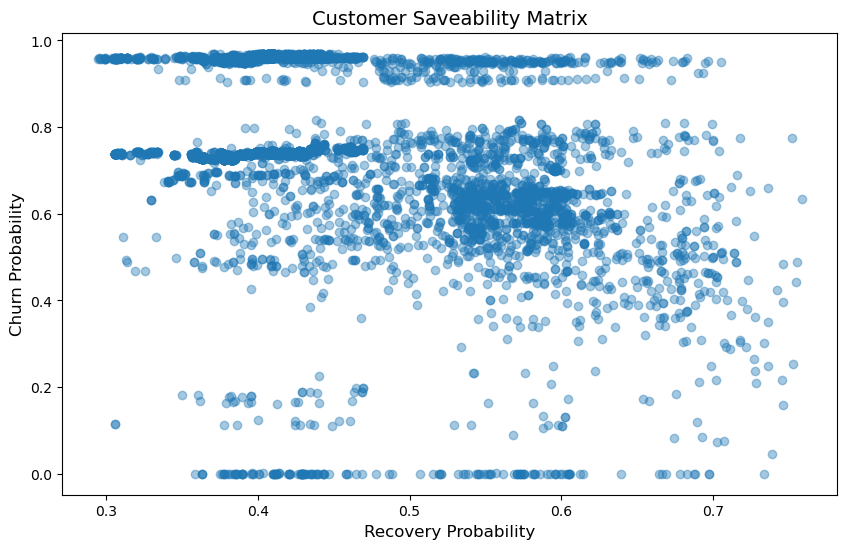

In [12]:
# =====================================================
# SAVEABILITY MATRIX
# =====================================================

import matplotlib.pyplot as plt

plot_df = results[
    results['Recovery_Probability'] > 0
]

plt.figure(figsize=(10,6))

plt.scatter(
    plot_df['Recovery_Probability'],
    plot_df['Churn_Probability'],
    alpha=0.4
)

plt.xlabel('Recovery Probability', fontsize=12)

plt.ylabel('Churn Probability', fontsize=12)

plt.title('Customer Saveability Matrix', fontsize=14)

plt.show()

**Key Findings**

Матрица Saveability показывает наличие значительного числа клиентов с одновременно высокой вероятностью оттока (0.5–0.9+) и умеренно высокой вероятностью восстановления (0.5–0.7). При этом зависимость между churn-risk и recovery probability выражена слабо: высокий риск ухода не означает автоматически низкую вероятность возврата. Существенная часть клиентской базы остается потенциально управляемой даже после появления признаков вероятного оттока.

Для бизнеса это означает, что риск оттока не является бинарной потерей клиента. Значительная доля пользователей, демонстрирующих признаки ухода, сохраняет потенциал для успешной реактивации и может приносить дополнительную выручку при своевременном вмешательстве. Следовательно, эффективность retention-программ определяется не количеством клиентов с высоким churn-risk, а способностью выделять среди них наиболее "спасаемых" пользователей. Это смещает фокус с прогнозирования оттока на прогнозирование эффективности удержания и повышает экономическую эффективность CRM-инвестиций.

Возможной причиной высокой recovery probability у части рискованных клиентов является сохранение базовой вовлеченности в категорию, программу лояльности или регулярные потребности в аптечных товарах. Также наблюдаемая картина может быть связана с тем, что снижение активности для многих клиентов носит временный характер и еще не перешло в устойчивую потерю покупательской привычки.

Retention-приоритизация должна учитывать не только вероятность ухода, но и вероятность успешного возврата. Высокий churn-risk без оценки saveability приводит к перерасходу CRM-бюджета на клиентов с низкой вероятностью отклика и снижает общий ROI удерживающих кампаний.

Приоритетными направлениями дальнейшего анализа и оптимизации являются:

1. Сформировать приоритетный сегмент High Churn Risk × High Recovery Probability для персонализированных retention-кампаний.  
2. Ограничить объем инвестиций в клиентов с высокой вероятностью ухода и низкой вероятностью восстановления.  
3. Использовать recovery score как обязательный критерий при запуске CRM-коммуникаций и распределении retention-бюджета.  
4. Тестировать механики реактивации отдельно для сегментов с различным уровнем saveability для повышения отклика.  

Интеграция recovery probability в процесс retention-приоритизации позволит повысить ROI CRM-активностей, увеличить долю успешно реактивированных клиентов и сократить маркетинговые затраты на аудиторию с низкой вероятностью возврата. В результате улучшатся показатели retention, recovered revenue и эффективность использования CRM-бюджета.

## Executive Summary

Анализ показал, что риск оттока в аптечной сети формируется задолго до фактической потери клиента и проявляется через постепенное ухудшение покупательского поведения: снижение частоты покупок, замедление роста выручки и увеличение интервалов между транзакциями. Построенная модель успешно выявляет такие изменения на ранней стадии (ROC-AUC = 0.89), что делает возможным переход от реактивного удержания к проактивному управлению клиентской базой.

Ключевой вывод заключается в том, что вероятность оттока не является достаточным критерием для принятия retention-решений. Основной финансовый риск сосредоточен не среди клиентов с максимальным churn-risk, а среди пользователей, которые одновременно обладают высокой ожидаемой ценностью, признаками ухудшения поведения и сохраняют потенциал восстановления активности. Следовательно, максимальный бизнес-эффект создаёт не массовое удержание клиентов, а приоритизация retention-инвестиций на основе ожидаемого revenue-at-risk и recovery potential.

### Ключевые инсайты

**1. Отток является процессом, а не событием**  
Наиболее значимыми предикторами churn-risk выступают Frequency, Monetary Growth, Monetary Delta и интервалы между покупками.   
Клиенты редко прекращают покупки резко. В большинстве случаев уходу предшествует постепенная деградация покупательского поведения.  
Компания получает возможность обнаруживать риск потери клиента до фактического оттока и запускать превентивные retention-механики.  

**2. Поведенческие тренды важнее статических RFM-показателей**  
Динамические признаки демонстрируют более высокий вклад в прогнозирование churn, чем абсолютные значения клиентской активности.  
Для оценки риска критично не текущее состояние клиента, а направление изменения его поведения.  
Retention-система должна отслеживать признаки ухудшения активности, а не только низкие значения RFM-метрик.  

**3. Высокий churn-risk не равен высокому бизнес-риску**  
Большинство клиентов из Critical Risk сегмента обладают низкой коммерческой ценностью и формируют ограниченный объём потенциальных потерь.  
Вероятность ухода и финансовая значимость клиента являются независимыми измерениями риска.  
Приоритизация удержания только по churn probability приводит к неэффективному распределению CRM-бюджета.   

**4. Основной Revenue-at-Risk сосредоточен в сегментах среднего риска**  
Наибольший объём потенциально теряемой выручки формируют клиенты Medium Risk и Low Risk, а не Critical Risk.  
Наиболее опасны клиенты, которые уже демонстрируют признаки деградации поведения, но ещё сохраняют высокий уровень ценности.  
Максимальный эффект retention достигается на стадии раннего ухудшения поведения, а не после перехода клиента в критические lifecycle-сегменты.  

**5. Значительная часть рискованных клиентов остаётся «спасаемой»**
Для многих клиентов высокий churn-risk сочетается с высокой вероятностью восстановления активности.  
Появление риска ухода не означает необратимую потерю клиента.  
Добавление recovery probability позволяет повысить ROI удерживающих кампаний и сократить неэффективные CRM-расходы.   
 
### Интерпретация результатов 

Результаты всех этапов анализа формируют единую поведенческую картину клиентского жизненного цикла.

Модель показывает, что снижение Frequency Growth, ухудшение Monetary Dynamics и увеличение времени между покупками являются первыми сигналами будущего оттока. Эти изменения возникают существенно раньше перехода клиента в стадии At Risk или Churn, что подтверждает существование периода ранней поведенческой деградации.

Одновременно анализ revenue-at-risk демонстрирует, что максимальную угрозу для бизнеса создают не клиенты с самым высоким риском ухода, а клиенты, у которых ухудшение поведения начинается на фоне всё ещё высокой коммерческой ценности. Именно в этой зоне пересекаются вероятность потери клиента и потенциальный финансовый ущерб.

Дополнительный анализ recovery potential показывает, что значительная часть таких пользователей сохраняет высокий потенциал возврата. Это означает, что поведенческая деградация не обязательно приводит к необратимому уходу и может быть скорректирована своевременными CRM-интервенциями.

Таким образом, наиболее эффективной стратегией является работа не с последствиями оттока, а с ранними признаками ухудшения поведения клиентов до наступления критических lifecycle-стадий.

### Влияние на бизнес  

**Риски**  
- Потеря высокоценных клиентов может приводить к непропорционально большим потерям выручки относительно масштаба клиентского оттока.  
- Фокус исключительно на churn probability создаёт риск неэффективного распределения retention-бюджета.  
- Позднее выявление деградации поведения сокращает вероятность успешной реактивации клиента и снижает эффективность CRM-коммуникаций.  
- Игнорирование динамических поведенческих сигналов может приводить к накоплению скрытого revenue-at-risk внутри внешне стабильных сегментов.  

**Возможности**  
- Раннее выявление churn-risk позволяет запускать превентивные retention-механики до потери клиента.  
- Использование Revenue-at-Risk обеспечивает более эффективное распределение маркетинговых инвестиций.  
- Интеграция Recovery Probability позволяет концентрировать ресурсы на клиентах с максимальной ожидаемой отдачей от удержания.  
- Переход к value-adjusted retention management способен повысить ROI CRM-коммуникаций без пропорционального роста маркетинговых расходов.  
- Формирование системы риск-ориентированного управления клиентской базой создаёт основу для долгосрочного роста клиентской ценности и повышения устойчивости выручки.

### Ограничения анализа
- Анализ основан на исторических observational data и выявляет статистические зависимости, но не позволяет однозначно подтверждать причинно-следственные связи.  
- Период наблюдения ограничен одним годом и может не полностью учитывать долгосрочные сезонные паттерны потребления.
- Recovery-модель оценивает вероятность восстановления на основе исторического поведения клиентов и не учитывает фактическое влияние будущих маркетинговых воздействий.  
- Оценка Expected Future Revenue строится на исторических паттернах монетизации и может изменяться под влиянием внешних факторов рынка.  
- Для окончательной оценки экономического эффекта retention-стратегий необходима последующая валидация через CRM-эксперименты и A/B-тестирование.

### Приоритетные направления работы   

**1. Внедрить систему раннего обнаружения churn-risk**  
Использовать изменения Frequency Growth, Monetary Growth и Purchase Cadence как опережающие сигналы ухудшения поведения и триггеры для CRM-коммуникаций.

**2. Перейти от churn management к Revenue-at-Risk management**  
Использовать показатель:  
Revenue-at-Risk = Expected Future Revenue × Churn Probability  
как основной критерий приоритизации удерживающих инвестиций.  

**3. Интегрировать Recovery Probability в CRM-процессы**  
Оценивать не только риск потери клиента, но и вероятность его успешного возврата перед запуском retention-кампаний.

**4. Выделить отдельный сегмент High Value × High Risk × High Recovery**  
Использовать для него персонализированные сценарии удержания, повышенный уровень CRM-поддержки и отдельный мониторинг эффективности.

**5. Провести экспериментальную валидацию модели**  
Запустить controlled retention campaigns для клиентов с высоким Retention Priority Score и измерить влияние на:
- retention rate,
- recovered revenue,
- incremental revenue,
- ROI CRM-инвестиций.

**6. Внедрить систему мониторинга клиентского риска**  
Отслеживать динамику:  
- Churn Probability,  
- Revenue-at-Risk,  
- Recovery Probability,  
- объёма выручки под риском по сегментам  
как отдельный слой регулярной управленческой отчётности.

### Итоговый бизнес-вывод 

Анализ показал, что максимальную ценность для бизнеса представляет не выявление клиентов с высокой вероятностью ухода, а выявление клиентов, чья потеря создаёт наибольший финансовый ущерб и при этом остаётся предотвратимой. Объединение churn prediction, customer value и recovery modeling формирует основу для перехода от массовых CRM-коммуникаций к системе data-driven retention management, ориентированной на сохранение будущей выручки и повышение эффективности инвестиций в удержание клиентов.